In [1]:
!pip install umap-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import umap
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Downloading CIFAR-10 via standard PyTorch...")
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=2)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

100%|██████████| 170M/170M [45:56<00:00, 61.9kB/s]


In [3]:
def setup_and_train_model(model, model_name, epochs=3):
    print(f"\n--- Setting up and training {model_name} ---")
    
    for param in model.parameters():
        param.requires_grad = False
        
    #replace classification head
    model.fc = nn.Linear(model.fc.in_features, 10)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    model = model.to(device)
    optimizer = optim.Adam(model.module.fc.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        print(f"Epoch [{epoch+1}/{epochs}] | {model_name} Train Loss: {running_loss / len(train_dataset):.4f}")
        
    return model

resnet152 = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
resnet152 = setup_and_train_model(resnet152, "ResNet-152")

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18 = setup_and_train_model(resnet18, "ResNet-18")

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 200MB/s]



--- Setting up and training ResNet-152 ---
Epoch [1/3] | ResNet-152 Train Loss: 0.8042
Epoch [2/3] | ResNet-152 Train Loss: 0.5247
Epoch [3/3] | ResNet-152 Train Loss: 0.4931
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


--- Setting up and training ResNet-18 ---


Epoch [1/3] | ResNet-18 Train Loss: 1.0374
Epoch [2/3] | ResNet-18 Train Loss: 0.6628
Epoch [3/3] | ResNet-18 Train Loss: 0.6097


Confusion matrix


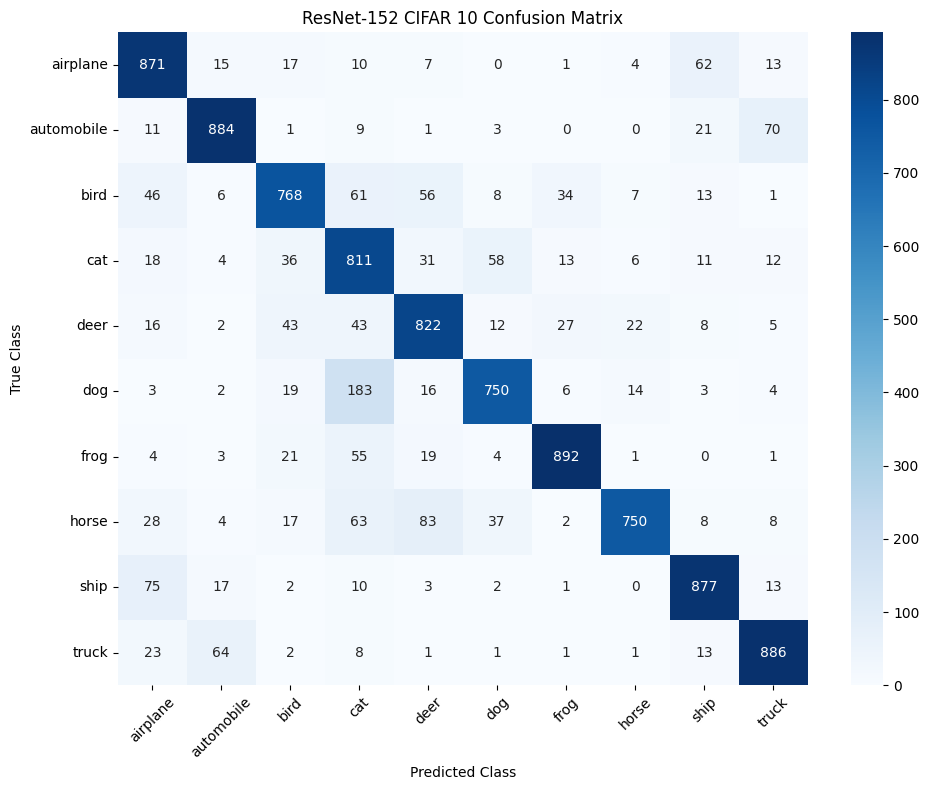

In [4]:
print("Confusion matrix")

resnet152.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = resnet152(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('ResNet-152 CIFAR 10 Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Computing t-SNE and UMAP embeddings (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


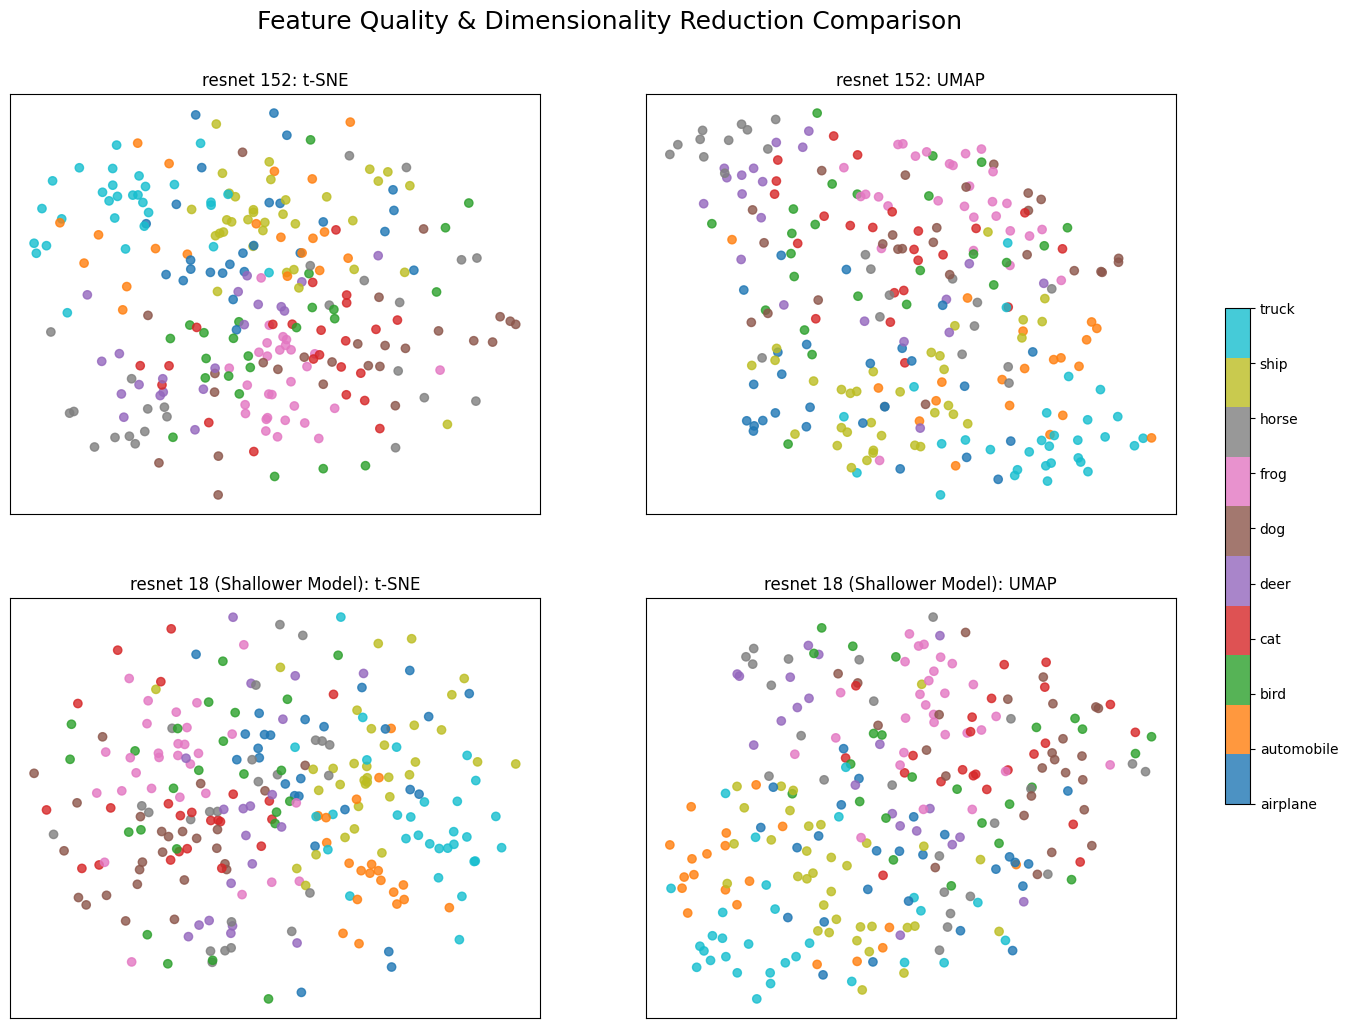

In [5]:

features = {}

def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach().cpu()
    return hook

base_152 = resnet152.module if isinstance(resnet152, torch.nn.DataParallel) else resnet152
base_18 = resnet18.module if isinstance(resnet18, torch.nn.DataParallel) else resnet18

handle_152 = base_152.layer4.register_forward_hook(get_features('resnet152_late'))
handle_18 = base_18.layer4.register_forward_hook(get_features('resnet18_late'))

data_iter = iter(val_loader)
images, labels = next(data_iter)
labels_np = labels.numpy()

base_152.eval()
base_18.eval()
with torch.no_grad():
    _ = base_152(images.to(device))
    _ = base_18(images.to(device))

#flattening features
feat_152 = features['resnet152_late'].view(features['resnet152_late'].size(0), -1).numpy()
feat_18 = features['resnet18_late'].view(features['resnet18_late'].size(0), -1).numpy()

print("Computing t-SNE and UMAP embeddings (this may take a minute)...")

tsne_152 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feat_152)
umap_152 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(feat_152)

tsne_18 = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feat_18)
umap_18 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(feat_18)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter1 = axes[0, 0].scatter(tsne_152[:, 0], tsne_152[:, 1], c=labels_np, cmap='tab10', alpha=0.8)
axes[0, 0].set_title('resnet 152: t-SNE')
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])

axes[0, 1].scatter(umap_152[:, 0], umap_152[:, 1], c=labels_np, cmap='tab10', alpha=0.8)
axes[0, 1].set_title('resnet 152: UMAP')
axes[0, 1].set_xticks([]); axes[0, 1].set_yticks([])

axes[1, 0].scatter(tsne_18[:, 0], tsne_18[:, 1], c=labels_np, cmap='tab10', alpha=0.8)
axes[1, 0].set_title('resnet 18 (Shallower Model): t-SNE')
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])

axes[1, 1].scatter(umap_18[:, 0], umap_18[:, 1], c=labels_np, cmap='tab10', alpha=0.8)
axes[1, 1].set_title('resnet 18 (Shallower Model): UMAP')
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([])

cbar = fig.colorbar(scatter1, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(CIFAR10_CLASSES)

plt.suptitle("Feature Quality & Dimensionality Reduction Comparison", fontsize=18, y=0.95)
plt.show()

#cleanup
handle_152.remove()
handle_18.remove()